# Student Performance Analytics & Prediction

## Notebook 6: Random Forest

### Objective

Train a Random Forest Regressor to predict students' final grades (G3) and compare its performance with Linear Regression and Decision Tree.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

## Model Selection

Random Forest is selected because it combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is one of the most powerful ensemble learning algorithms for regression tasks.

In [3]:
df = pd.read_csv("../data/student-por.csv")
x=df.drop("G3",axis=1)
y=df["G3"]

X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)
categorical_cols=X_train.select_dtypes(include="object").columns.tolist()
numerical_cols=X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols),("num",StandardScaler(),numerical_cols)])

## Save Trained Model

The trained Random Forest pipeline is saved as a `.pkl` file so that it can be reused later in the Flask application without retraining the model.

In [4]:
model=Pipeline([("preprocessor",preprocessor),("regressor",RandomForestRegressor( n_estimators=100,random_state=42))])
model.fit(X_train,y_train)

import joblib
joblib.dump(model, "../models/best_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [5]:
y_pred=model.predict(X_test)
prediction_df = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred.round(2)})
prediction_df.head(10)

,Actual,Predicted
0,19,17.23
1,12,11.05
2,18,17.27
3,11,11.02
4,11,11.19
5,17,16.33
6,18,17.49
7,8,9.92
8,10,10.32
9,11,10.38


In [6]:
y_pred = model.predict(X_test)

print("Maximum Predicted Grade:", y_pred.max())
print("Minimum Predicted Grade:", y_pred.min())

print("Maximum Actual Grade:", y_test.max())
print("Minimum Actual Grade:", y_test.min())

Maximum Predicted Grade: 17.83
Minimum Predicted Grade: 1.41
Maximum Actual Grade: 19
Minimum Actual Grade: 0


In [7]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=mse**0.5
r2=r2_score(y_test,y_pred)

print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))

MAE : 0.75
MSE : 1.54
RMSE: 1.24
R2 Score: 0.84


## Evaluation Metrics

### Observation

- The Random Forest model achieved an MAE of 0.75
- The RMSE is 1.24
- The model achieved an R² score of 0.84

### Insight

- Lower MAE and RMSE indicate good prediction accuracy
- A higher R² score indicates that the model explains a large portion of the variation in students' final grades

### Possible Action

- Compare these results with Linear Regression and Decision Tree
- Select the best-performing model for deployment

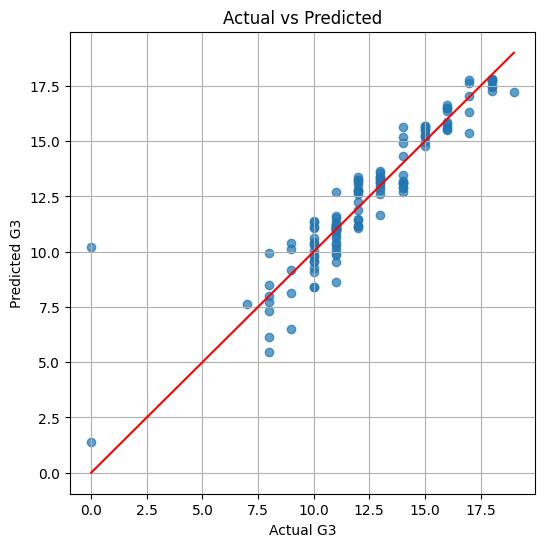

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,alpha=0.7)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted")

plt.grid()
plt.show()

## Scatter Plot Analysis

### Observation

- Most predicted values lie close to the diagonal line.
- A few predictions deviate from the actual values.

### Insight

- Points closer to the diagonal indicate better prediction accuracy.
- Random Forest captures the relationship between features and the target variable effectively.

### Possible Action

- Compare the scatter plot with previous models to identify which model predicts more accurately.

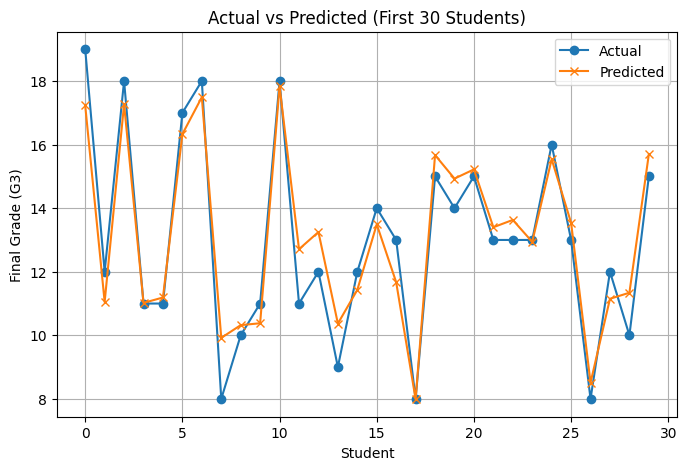

In [9]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values[:30], label="Actual", marker="o")
plt.plot(y_pred[:30], label="Predicted", marker="x")

plt.title("Actual vs Predicted (First 30 Students)")
plt.xlabel("Student")
plt.ylabel("Final Grade (G3)")

plt.legend()
plt.grid() 
plt.show()

## Actual vs Predicted Comparison

### Observation

- The predicted grades follow the trend of the actual grades.
- Small differences exist between actual and predicted values.

### Insight

- The model captures the overall pattern of students' final grades.
- Minor deviations indicate normal prediction errors.

### Possible Action

- Compare these results with other regression models.

## Final Conclusion

- The Random Forest model successfully predicted students' final grades.
- The model achieved an MAE of 0.75, an RMSE of 1.24, and an R² score of 0.84.
- Random Forest reduced prediction errors and is expected to perform better than a single Decision Tree.
- The next notebook will compare the performance of all trained models and identify the best one.